In [2]:
import pandas as pd

df = pd.read_excel("Sydney_housing_FINAL_CLEANED_NO_TIME.xlsx")

df.head()

,Suburb,Sale Price,Bedrooms,Bathrooms,Parking,Land Size,Property Type,Sale Date,Property Address
0,Blacktown,"$980,000",3.0,1.0,2.0,613 m²,House,2026-09-18,49 Pendant Avenue
1,Blacktown,"$1,350,000",5.0,3.0,3.0,338 m²,House,2026-09-17,40 Stephen Street
2,Blacktown,"$900,000",3.0,1.0,3.0,556 m²,House,2026-09-17,199 Flushcombe Road
3,Blacktown,"$1,105,000",3.0,1.0,3.0,739.8 m²,House,2026-09-16,6 Oregon Street
4,Blacktown,"$1,135,000",3.0,2.0,4.0,765 m²,House,2026-09-15,7 Highlands Crescent


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 121
Columns: 9


In [4]:
df.isnull().sum()

Suburb               0
Sale Price           0
Bedrooms             2
Bathrooms            3
Parking              8
Land Size           39
Property Type        0
Sale Date            0
Property Address     0
dtype: int64

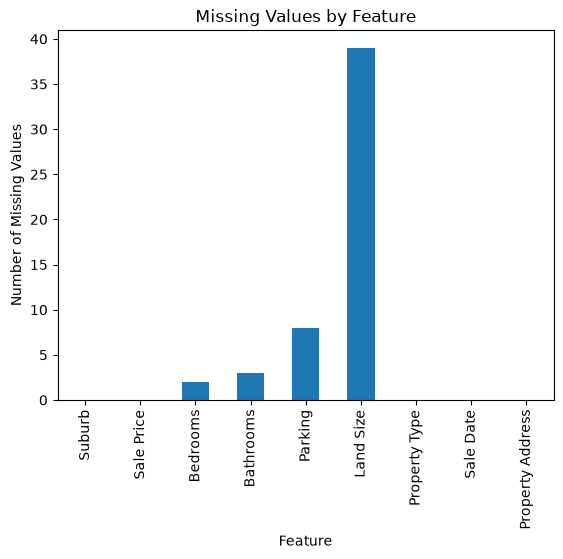

In [5]:
import matplotlib.pyplot as plt

df.isnull().sum().plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.show()

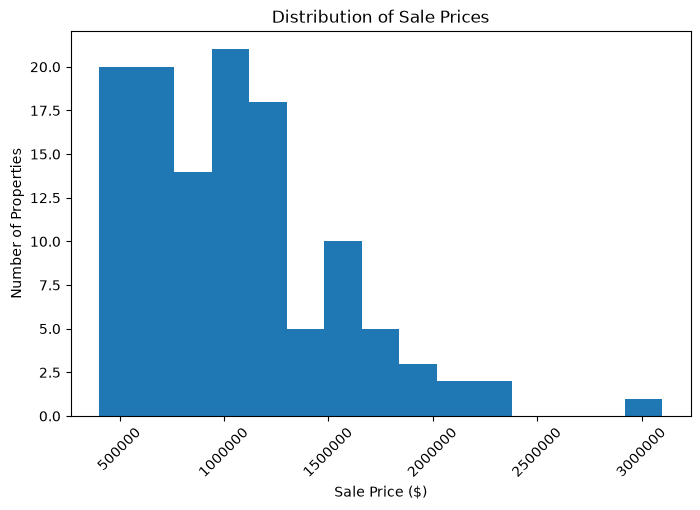

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["Sale Price"], bins=15)

plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")

plt.ticklabel_format(style="plain", axis="x")
plt.xticks(rotation=45)

plt.show()

In [9]:
df.groupby("Suburb")["Sale Price"].mean()

Suburb
Blacktown     1.107600e+06
Liverpool     1.142233e+06
Parramatta    9.762951e+05
Name: Sale Price, dtype: float64

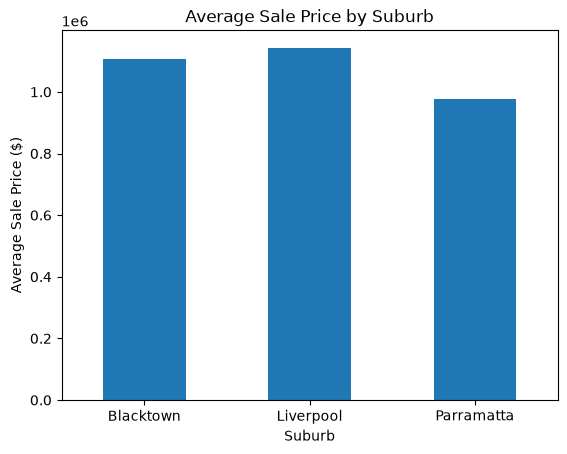

In [10]:
df.groupby("Suburb")["Sale Price"].mean().plot(kind="bar")

plt.title("Average Sale Price by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Average Sale Price ($)")
plt.xticks(rotation=0)
plt.show()

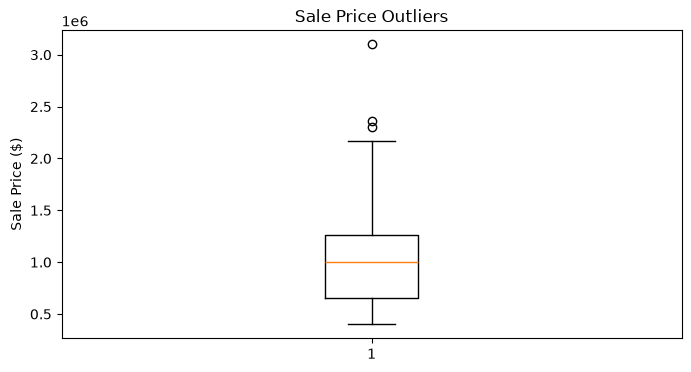

In [11]:
plt.figure(figsize=(8,4))

plt.boxplot(df["Sale Price"])

plt.title("Sale Price Outliers")
plt.ylabel("Sale Price ($)")
plt.show()

In [13]:
df["Land Size"] = (
    df["Land Size"]
    .astype(str)
    .str.replace("m²", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", None)
)

df["Land Size"] = pd.to_numeric(df["Land Size"], errors="coerce")

In [14]:
df[["Sale Price", "Bedrooms", "Bathrooms", "Land Size"]].corr()

,Sale Price,Bedrooms,Bathrooms,Land Size
Sale Price,1.000000,0.703591,0.516215,0.680729
Bedrooms,0.703591,1.000000,0.880153,0.588520
Bathrooms,0.516215,0.880153,1.000000,0.360461
Land Size,0.680729,0.588520,0.360461,1.000000


In [15]:
df["Total Rooms"] = df["Bedrooms"] + df["Bathrooms"]

df[["Bedrooms", "Bathrooms", "Total Rooms"]].head()

,Bedrooms,Bathrooms,Total Rooms
0,3.0,1.0,4.0
1,5.0,3.0,8.0
2,3.0,1.0,4.0
3,3.0,1.0,4.0
4,3.0,2.0,5.0


In [18]:
from sklearn.model_selection import train_test_split

X = df[
    ["Suburb", "Bedrooms", "Bathrooms", "Parking",
     "Land Size", "Property Type", "Total Rooms"]
]

y = df["Sale Price"]

print(X.shape)
print(y.shape)

(121, 7)
(121,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (96, 7)
Testing: (25, 7)


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "Bedrooms", "Bathrooms", "Parking",
    "Land Size", "Total Rooms"
]

categorical_features = [
    "Suburb", "Property Type"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing setup complete")

Preprocessing setup complete


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

print("3 models ready")

3 models ready


In [22]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        }
    )

    results[name] = {
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": scores["test_R2"].mean()
    }

results

{'Linear Regression': {'MAE': np.float64(142210.00080368415),
  'RMSE': np.float64(190626.17539859755),
  'R2': np.float64(0.7766499001136284)},
 'Random Forest': {'MAE': np.float64(139987.96921593757),
  'RMSE': np.float64(188284.92832413365),
  'R2': np.float64(0.8076273437670738)},
 'Gradient Boosting': {'MAE': np.float64(145916.46432514692),
  'RMSE': np.float64(200337.57011751193),
  'R2': np.float64(0.7808353390481131)}}

In [23]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 199371.2525063825
RMSE: 361217.67671140865
R²: 0.6399868858491053


In [25]:
errors = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

errors["Error"] = errors["Actual Price"] - errors["Predicted Price"]
errors["Absolute Error"] = abs(errors["Error"])

errors["Property Address"] = df.loc[
    errors.index, "Property Address"
]

errors.sort_values(
    "Absolute Error",
    ascending=False
).head(5)

,Actual Price,Predicted Price,Error,Absolute Error,Property Address
47,3100000.0,1.773968e+06,1.326032e+06,1.326032e+06,1 Leitz Street
31,2000000.0,1.220028e+06,7.799725e+05,7.799725e+05,3 Secant Street
118,2170000.0,1.462945e+06,7.070550e+05,7.070550e+05,84 Crimea Street
89,2080000.0,1.785355e+06,2.946450e+05,2.946450e+05,33 Rosehill St
64,575000.0,8.690963e+05,-2.940963e+05,2.940963e+05,610/36-46 Cowper Street


In [26]:
top5 = errors.sort_values(
    "Absolute Error",
    ascending=False
).head(5)

df.loc[top5.index, [
    "Suburb",
    "Sale Price",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Land Size",
    "Property Type",
    "Property Address"
]]

,Suburb,Sale Price,Bedrooms,Bathrooms,Parking,Land Size,Property Type,Property Address
47,Liverpool,3100000.0,24.0,14.0,6.0,1358.0,House,1 Leitz Street
31,Liverpool,2000000.0,4.0,2.0,2.0,676.0,House,3 Secant Street
118,Parramatta,2170000.0,5.0,3.0,2.0,303.0,House,84 Crimea Street
89,Parramatta,2080000.0,4.0,1.0,1.0,691.0,House,33 Rosehill St
64,Parramatta,575000.0,NaN,NaN,NaN,NaN,Apartment,610/36-46 Cowper Street


In [27]:
comparison = df.loc[y_test.index, [
    "Suburb",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Land Size",
    "Property Type",
    "Property Address",
    "Sale Price"
]].copy()

comparison["ML Prediction"] = y_pred

comparison.head(10)

,Suburb,Bedrooms,Bathrooms,Parking,Land Size,Property Type,Property Address,Sale Price,ML Prediction
44,Liverpool,3.0,2.0,1.0,NaN,House,5/10 Christie Street,870000.0,1.091616e+06
47,Liverpool,24.0,14.0,6.0,1358.0,House,1 Leitz Street,3100000.0,1.773968e+06
4,Blacktown,3.0,2.0,4.0,765.0,House,7 Highlands Crescent,1135000.0,1.246938e+06
55,Liverpool,3.0,1.0,2.0,559.0,House,32 Gill Avenue,1160000.0,1.061636e+06
26,Blacktown,3.0,2.0,3.0,600.7,House,59 Lancaster Street,900000.0,1.015788e+06
64,Parramatta,NaN,NaN,NaN,NaN,Apartment,610/36-46 Cowper Street,575000.0,8.690963e+05
73,Parramatta,2.0,1.0,1.0,104.0,Unit,3/23 Good Street,569000.0,5.687982e+05
10,Blacktown,3.0,1.0,1.0,575.4,House,19 Stephen Street,1062500.0,9.417050e+05
40,Liverpool,3.0,2.0,1.0,233.0,Townhouse,4/44-46 Passefield Street,875000.0,1.007405e+06
108,Parramatta,3.0,2.0,2.0,204.0,Townhouse,10/43 Pemberton Street,1101500.0,1.113995e+06


In [29]:
comparison10 = comparison.head(10).copy()

comparison10

,Suburb,Bedrooms,Bathrooms,Parking,Land Size,Property Type,Property Address,Sale Price,ML Prediction
44,Liverpool,3.0,2.0,1.0,NaN,House,5/10 Christie Street,870000.0,1.091616e+06
47,Liverpool,24.0,14.0,6.0,1358.0,House,1 Leitz Street,3100000.0,1.773968e+06
4,Blacktown,3.0,2.0,4.0,765.0,House,7 Highlands Crescent,1135000.0,1.246938e+06
55,Liverpool,3.0,1.0,2.0,559.0,House,32 Gill Avenue,1160000.0,1.061636e+06
26,Blacktown,3.0,2.0,3.0,600.7,House,59 Lancaster Street,900000.0,1.015788e+06
64,Parramatta,NaN,NaN,NaN,NaN,Apartment,610/36-46 Cowper Street,575000.0,8.690963e+05
73,Parramatta,2.0,1.0,1.0,104.0,Unit,3/23 Good Street,569000.0,5.687982e+05
10,Blacktown,3.0,1.0,1.0,575.4,House,19 Stephen Street,1062500.0,9.417050e+05
40,Liverpool,3.0,2.0,1.0,233.0,Townhouse,4/44-46 Passefield Street,875000.0,1.007405e+06
108,Parramatta,3.0,2.0,2.0,204.0,Townhouse,10/43 Pemberton Street,1101500.0,1.113995e+06


LLM-Based Property Valuation

Tool: ChatGPT

Objective: To obtain independent property value estimates and compare them with the machine learning model's predictions and actual sale prices.

Prompt:

"Act as a property valuation assistant. Estimate the market value in AUD for each property using the available characteristics, including suburb, property type, bedrooms, bathrooms, parking spaces, and land size. Do not use the actual sale price or machine learning predictions. Provide a numerical estimate for each property in the same order as the input data, along with a brief explanation of the factors considered."

In [30]:
comparison10["ChatGPT Prediction"] = [
    950000,
    2500000,
    1150000,
    1050000,
    950000,
    600000,
    570000,
    1000000,
    850000,
    1050000
]

comparison10

,Suburb,Bedrooms,Bathrooms,Parking,Land Size,Property Type,Property Address,Sale Price,ML Prediction,ChatGPT Prediction
44,Liverpool,3.0,2.0,1.0,NaN,House,5/10 Christie Street,870000.0,1.091616e+06,950000
47,Liverpool,24.0,14.0,6.0,1358.0,House,1 Leitz Street,3100000.0,1.773968e+06,2500000
4,Blacktown,3.0,2.0,4.0,765.0,House,7 Highlands Crescent,1135000.0,1.246938e+06,1150000
55,Liverpool,3.0,1.0,2.0,559.0,House,32 Gill Avenue,1160000.0,1.061636e+06,1050000
26,Blacktown,3.0,2.0,3.0,600.7,House,59 Lancaster Street,900000.0,1.015788e+06,950000
64,Parramatta,NaN,NaN,NaN,NaN,Apartment,610/36-46 Cowper Street,575000.0,8.690963e+05,600000
73,Parramatta,2.0,1.0,1.0,104.0,Unit,3/23 Good Street,569000.0,5.687982e+05,570000
10,Blacktown,3.0,1.0,1.0,575.4,House,19 Stephen Street,1062500.0,9.417050e+05,1000000
40,Liverpool,3.0,2.0,1.0,233.0,Townhouse,4/44-46 Passefield Street,875000.0,1.007405e+06,850000
108,Parramatta,3.0,2.0,2.0,204.0,Townhouse,10/43 Pemberton Street,1101500.0,1.113995e+06,1050000


In [31]:
comparison10["Human Prediction"] = 0

Human Estimation Rationale
Property ID	Human Estimate	Reasoning
44	$90,000	Estimated based on Liverpool's location, the property's 3 bedrooms, 2 bathrooms, and availability of parking.

47	$200,000	A higher estimate was assigned due to the larger property configuration, including 24 bedrooms, 14 bathrooms, 6 parking spaces, and 1,358 m² of land.

4	$115,000	Considered the property's 765 m² land size, 3 bedrooms, 2 bathrooms, and 4 parking spaces when estimating its value.

55	$110,000	Estimated based on the property's 3 bedrooms, 559 m² land size, and 2 parking spaces, while accounting for its single bathroom.

26	$95,000	Considered the 3-bedroom configuration, 600.7 m² land size, and 3 parking spaces in Blacktown.

64	$60,000	Estimated using the property's apartment classification and Parramatta location, with limited information available about its features.

73	$57,000	Based on the property's 2 bedrooms, 1 bathroom, 104 m² land size, and unit classification.

10	$100,000	Considered the property's 3 bedrooms, 1 bathroom, 575.4 m² land size, and location in Blacktown.

40	$85,000	Estimated based on the townhouse classification, 3 bedrooms, 2 bathrooms, and 233 m² land size.

108	$110,000	Considered the property's 3 bedrooms, 2 bathrooms, 2 parking spaces, and 204 m² land size in Parramatta.

In [32]:
comparison10["Human Prediction"] = [
    900000,
    2000000,
    1150000,
    1100000,
    950000,
    600000,
    570000,
    1000000,
    850000,
    1100000
]

comparison10

,Suburb,Bedrooms,Bathrooms,Parking,Land Size,Property Type,Property Address,Sale Price,ML Prediction,ChatGPT Prediction,Human Prediction
44,Liverpool,3.0,2.0,1.0,NaN,House,5/10 Christie Street,870000.0,1.091616e+06,950000,900000
47,Liverpool,24.0,14.0,6.0,1358.0,House,1 Leitz Street,3100000.0,1.773968e+06,2500000,2000000
4,Blacktown,3.0,2.0,4.0,765.0,House,7 Highlands Crescent,1135000.0,1.246938e+06,1150000,1150000
55,Liverpool,3.0,1.0,2.0,559.0,House,32 Gill Avenue,1160000.0,1.061636e+06,1050000,1100000
26,Blacktown,3.0,2.0,3.0,600.7,House,59 Lancaster Street,900000.0,1.015788e+06,950000,950000
64,Parramatta,NaN,NaN,NaN,NaN,Apartment,610/36-46 Cowper Street,575000.0,8.690963e+05,600000,600000
73,Parramatta,2.0,1.0,1.0,104.0,Unit,3/23 Good Street,569000.0,5.687982e+05,570000,570000
10,Blacktown,3.0,1.0,1.0,575.4,House,19 Stephen Street,1062500.0,9.417050e+05,1000000,1000000
40,Liverpool,3.0,2.0,1.0,233.0,Townhouse,4/44-46 Passefield Street,875000.0,1.007405e+06,850000,850000
108,Parramatta,3.0,2.0,2.0,204.0,Townhouse,10/43 Pemberton Street,1101500.0,1.113995e+06,1050000,1100000


In [33]:
comparison10["ML Error"] = abs(
    comparison10["Sale Price"] - comparison10["ML Prediction"]
)

comparison10["ChatGPT Error"] = abs(
    comparison10["Sale Price"] - comparison10["ChatGPT Prediction"]
)

comparison10["Human Error"] = abs(
    comparison10["Sale Price"] - comparison10["Human Prediction"]
)

comparison10[
    ["Property Address", "Sale Price",
     "ML Error", "ChatGPT Error", "Human Error"]
]

,Property Address,Sale Price,ML Error,ChatGPT Error,Human Error
44,5/10 Christie Street,870000.0,2.216160e+05,80000.0,30000.0
47,1 Leitz Street,3100000.0,1.326032e+06,600000.0,1100000.0
4,7 Highlands Crescent,1135000.0,1.119375e+05,15000.0,15000.0
55,32 Gill Avenue,1160000.0,9.836400e+04,110000.0,60000.0
26,59 Lancaster Street,900000.0,1.157875e+05,50000.0,50000.0
64,610/36-46 Cowper Street,575000.0,2.940963e+05,25000.0,25000.0
73,3/23 Good Street,569000.0,2.017857e+02,1000.0,1000.0
10,19 Stephen Street,1062500.0,1.207950e+05,62500.0,62500.0
40,4/44-46 Passefield Street,875000.0,1.324050e+05,25000.0,25000.0
108,10/43 Pemberton Street,1101500.0,1.249500e+04,51500.0,1500.0


In [34]:
comparison10[[
    "ML Error",
    "ChatGPT Error",
    "Human Error"
]].mean()

ML Error         243373.061931
ChatGPT Error    102000.000000
Human Error      137000.000000
dtype: float64

In [35]:
import joblib

joblib.dump(best_model, "housing_price_model.pkl")

print("Model saved successfully")

Model saved successfully


In [36]:
pd.DataFrame(results).T

,MAE,RMSE,R2
Linear Regression,142210.000804,190626.175399,0.776650
Random Forest,139987.969216,188284.928324,0.807627
Gradient Boosting,145916.464325,200337.570118,0.780835
